In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy import special

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian, sl, lorentzian, fermi_dirac, is_converged

In [ ]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x = pbc_x
        self.pbc_y = pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return np.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = np.subtract(rj, ri)  # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr

    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"

    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if (x < edge_width or x >= X - edge_width or
                        y < edge_width or y >= Y - edge_width):
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                 edgecolor="none",
                                                 boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


class Hamiltonian:
    def __init__(self, t, mu, lattice,
                 U=None, V=None, V_prime=None,
                 F0_init=0, F_init=np.zeros(4),
                 Fuu_init=np.zeros(4),
                 Fdd_init=np.zeros(4)):
        '''
        Sets the hamiltonian parameters and initial conditions
        '''
        self.t = t
        self.mu = mu
        self.lattice = lattice
        Nx = lattice.X
        self.dim = 4 * Nx
        self.free = 0

        if U is None:
            U = np.zeros(Nx)
        if V is None:
            V = np.zeros(Nx)
        if V_prime is None:
            V_prime = np.zeros(Nx)
        self.U = U
        self.V = V
        self.V_prime = V_prime

        self.F0 = np.zeros(Nx, dtype=np.complex128)
        self.F0[np.where(U != 0)] = F0_init
        self.F_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.F_xplus[np.where(V[1:] != 0)] = F_init[0]
        self.F_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.F_xmin[np.where(V[:-1] != 0)] = F_init[1]
        self.F_yplus = np.zeros(Nx, dtype=np.complex128)
        self.F_yplus[np.where(V != 0)] = F_init[2]
        self.F_ymin = np.zeros(Nx, dtype=np.complex128)
        self.F_ymin[np.where(V != 0)] = F_init[3]

        self.Fuu_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.Fuu_xplus[np.where(V_prime[:-1] != 0)] = Fuu_init[0]
        self.Fuu_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.Fuu_xmin[np.where(V_prime[1:] != 0)] = Fuu_init[1]
        self.Fuu_yplus = np.zeros(Nx, dtype=np.complex128)
        self.Fuu_yplus[np.where(V_prime != 0)] = Fuu_init[2]
        self.Fuu_ymin = np.zeros(Nx, dtype=np.complex128)
        self.Fuu_ymin[np.where(V_prime != 0)] = Fuu_init[3]

        self.Fdd_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.Fdd_xplus[np.where(V_prime[:-1] != 0)] = Fdd_init[0]
        self.Fdd_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.Fdd_xmin[np.where(V_prime[1:] != 0)] = Fdd_init[1]
        self.Fdd_yplus = np.zeros(Nx, dtype=np.complex128)
        self.Fdd_yplus[np.where(V_prime != 0)] = Fdd_init[2]
        self.Fdd_ymin = np.zeros(Nx, dtype=np.complex128)
        self.Fdd_ymin[np.where(V_prime != 0)] = Fdd_init[3]

    def get_dim(self):
        return self.dim

    def build_H_k0(self):
        H = np.zeros((self.dim, self.dim), dtype=np.complex128)

        gap_y1 = self.V * (self.F_yplus + self.F_ymin)
        gap_y2 = -self.V * (self.F_yplus + self.F_ymin)

        for i in range(self.lattice.X):
            H[sl(i, 0), sl(i, 0)] = -2 * self.t
            H[sl(i, 1), sl(i, 1)] = -2 * self.t
            H[sl(i, 2), sl(i, 2)] = 2 * self.t
            H[sl(i, 3), sl(i, 3)] = 2 * self.t

            H[sl(i, 0), sl(i, 3)] = gap_y1[i]
            H[sl(i, 1), sl(i, 2)] = gap_y2[i]
            H[sl(i, 2), sl(i, 1)] = np.conj(gap_y2[i])
            H[sl(i, 3), sl(i, 0)] = np.conj(gap_y1[i])
        return H

    def build_H_kindep(self):
        gap0 = self.U * self.F0
        gap_x1 = self.V[1:] * self.F_xmin
        gap_x2 = self.V[:-1] * self.F_xplus

        gap_x1_uu = self.V_prime[1:] * self.Fuu_xmin
        gap_x2_uu = self.V_prime[:-1] * self.Fuu_xplus
        gap_x1_dd = self.V_prime[1:] * self.Fuu_xmin
        gap_x2_dd = self.V_prime[:-1] * self.Fuu_xplus

        H = np.zeros((self.dim, self.dim), dtype=np.complex128)

        for i in range(self.lattice.X):
            H[sl(i, 0), sl(i, 0)] = -self.mu[i]
            H[sl(i, 1), sl(i, 1)] = -self.mu[i]
            H[sl(i, 2), sl(i, 2)] = self.mu[i]
            H[sl(i, 3), sl(i, 3)] = self.mu[i]

            H[sl(i, 0), sl(i, 3)] = gap0[i]
            H[sl(i, 1), sl(i, 2)] = -gap0[i]
            H[sl(i, 2), sl(i, 1)] = np.conj(-gap0[i])
            H[sl(i, 3), sl(i, 0)] = np.conj(gap0[i])

        for i in range(self.lattice.X - 1):
            for c, hop in enumerate([-self.t, -self.t, self.t, self.t]):
                H[sl(i, c),   sl(i + 1, c)] = hop
                H[sl(i + 1, c), sl(i, c)] = hop

            # upper
            H[sl(i, 0), sl(i+1, 3)] = gap_x2[i]
            H[sl(i, 1), sl(i+1, 2)] = -gap_x1[i]
            H[sl(i, 2), sl(i+1, 1)] = np.conj(-gap_x2[i])
            H[sl(i, 3), sl(i+1, 0)] = np.conj(gap_x1[i])

            H[sl(i, 0), sl(i, 2)] = gap_x2_uu[i]
            H[sl(i, 1), sl(i, 3)] = gap_x2_dd[i]
            H[sl(i, 2), sl(i, 0)] = np.conj(gap_x1_uu[i])
            H[sl(i, 3), sl(i, 1)] = np.conj(gap_x1_dd[i])

            # lower
            H[sl(i+1, 0), sl(i, 3)] = gap_x1[i]
            H[sl(i+1, 1), sl(i, 2)] = -gap_x2[i]
            H[sl(i+1, 2), sl(i, 1)] = np.conj(-gap_x1[i])
            H[sl(i+1, 3), sl(i, 0)] = np.conj(gap_x2[i])

            H[sl(i, 0), sl(i, 2)] = gap_x1_uu[i]
            H[sl(i, 1), sl(i, 3)] = gap_x1_dd[i]
            H[sl(i, 2), sl(i, 0)] = np.conj(gap_x2_uu[i])
            H[sl(i, 3), sl(i, 1)] = np.conj(gap_x2_dd[i])

        return H

    def build_H_k(self, k):
        H2 = np.zeros((self.dim, self.dim), dtype=np.complex128)

        epsilon = -2 * self.t * np.cos(k)
        ep = np.exp(1j * k)
        em = np.exp(-1j * k)

        # y-pairing with phase
        gap1 = self.V * (self.F_yplus * em + self.F_ymin * ep)
        gap2 = -self.V * (self.F_yplus * ep + self.F_ymin * em)
        gap_uu = -1j * self.V_prime * self.Fuu_yplus * np.sin(k)
        gap_dd = -1j * self.V_prime * self.Fdd_yplus * np.sin(k)

        for i in range(self.lattice.X):
            # dispersion
            H2[sl(i, 0), sl(i, 0)] = epsilon
            H2[sl(i, 1), sl(i, 1)] = epsilon
            H2[sl(i, 2), sl(i, 2)] = -epsilon
            H2[sl(i, 3), sl(i, 3)] = -epsilon

            H2[sl(i, 0), sl(i, 3)] = gap1[i]
            H2[sl(i, 1), sl(i, 2)] = gap2[i]
            H2[sl(i, 2), sl(i, 1)] = np.conj(gap2[i])
            H2[sl(i, 3), sl(i, 0)] = np.conj(gap1[i])

            H2[sl(i, 0), sl(i, 2)] = gap_uu[i]
            H2[sl(i, 1), sl(i, 3)] = gap_dd[i]
            H2[sl(i, 2), sl(i, 0)] = np.conj(gap_uu[i])  # TODO: Check sign
            H2[sl(i, 3), sl(i, 1)] = np.conj(gap_dd[i])

        return H2

    def set_correlations(self, corr):
        self.F0 = corr[0].copy()

        self.F_xplus = corr[1].copy()
        self.F_xmin = corr[2].copy()
        self.F_yplus = corr[3].copy()
        self.F_ymin = corr[4].copy()

        self.Fuu_xplus = corr[5].copy()
        self.Fuu_xmin = corr[6].copy()
        self.Fuu_yplus = corr[7].copy()
        self.Fuu_ymin = corr[8].copy()

        self.Fdd_xplus = corr[9].copy()
        self.Fdd_xmin = corr[10].copy()
        self.Fdd_yplus = corr[11].copy()
        self.Fdd_ymin = corr[12].copy()

    def free_energy_const_term(self):
        E_S = 0

        E_S += np.sum(self.U * np.abs(self.F0)**2)

        E_S += np.sum(self.V * np.abs(np.r_[0, self.F_xplus])**2)
        E_S += np.sum(self.V * np.abs(np.r_[self.F_xmin, 0])**2)
        E_S += np.sum(self.V * np.abs(self.F_yplus)**2)
        E_S += np.sum(self.V * np.abs(self.F_ymin)**2)

        E_S += np.sum(self.V_prime * np.abs(np.r_[0, self.Fuu_xplus])**2)
        E_S += np.sum(self.V_prime * np.abs(np.r_[self.Fuu_xmin, 0])**2)
        E_S += np.sum(self.V_prime * np.abs(self.Fuu_yplus)**2)
        E_S += np.sum(self.V_prime * np.abs(self.Fuu_ymin)**2)

        E_S += np.sum(self.V_prime * np.abs(np.r_[0, self.Fdd_xplus])**2)
        E_S += np.sum(self.V_prime * np.abs(np.r_[self.Fdd_xmin, 0])**2)
        E_S += np.sum(self.V_prime * np.abs(self.Fdd_yplus)**2)
        E_S += np.sum(self.V_prime * np.abs(self.Fdd_ymin)**2)

        return E_S

    def free_energy(self, temperature=0):
        '''Calculates free energy and set it in H'''
        Ny = self.lattice.Y
        ky_list = np.linspace(PI / Ny, PI, Ny)

        H_kindep = self.build_H_kindep()
        H_k0 = self.build_H_k0()

        eigval0 = la.eigvalsh(
            H_kindep + H_k0,
            subset_by_value=(0, np.inf)
        )
        if not temperature == 0:
            beta = 1/temperature
            S = np.sum(special.softplus(-eigval0*beta))/beta
        else:
            S = 0
        free = -sum(eigval0)/2 - S

        for k in ky_list:
            H_k = self.build_H_k(k)
            if k == PI:
                eigval = la.eigvalsh(
                    H_kindep + H_k,
                    subset_by_value=(0, np.inf)
                )
            else:
                eigval = la.eigvalsh(H_kindep + H_k)

            if not temperature == 0:
                beta = 1/temperature
                S = np.sum(special.softplus(-eigval*beta))/beta
            else:
                S = 0
            free = free - np.sum(eigval)/2 - S

        E_S = self.free_energy_const_term()

        free = free - E_S
        self.free = free
        return free

    def dos_k(self, energies, eta, H_kindep, k):

        H_k = self.build_H_k(k)
        H2 = H_kindep + H_k

        eigval, eigvec = la.eigh(H2)

        u_up = eigvec[0::4, :]  # electron ↑
        u_dn = eigvec[1::4, :]  # electron ↓
        v_up = eigvec[2::4, :]  # hole ↑
        v_dn = eigvec[3::4, :]  # hole ↓

        w_pos = np.sum(np.abs(u_up)**2 + np.abs(u_dn)**2, axis=0)  # (M,)
        w_neg = np.sum(np.abs(v_up)**2 + np.abs(v_dn)**2, axis=0)

        Lp = lorentzian(energies[:, None] - eigval[None, :], eta=eta)
        Ln = lorentzian(energies[:, None] + eigval[None, :], eta=eta)

        dos_values = (np.einsum('nm,m->n', Lp, w_pos)
                      + np.einsum('nm,m->n', Ln, w_neg))
        return dos_values

    def dos(self, energies, eta):
        Ny = self.lattice.Y
        ky_list = np.linspace(PI/Ny, PI, Ny, endpoint=False)

        H_kindep = self.build_H_kindep()
        H_k0 = self.build_H_k0()

        eigval0, eigvec0 = la.eigh(
            H_kindep + H_k0,
            subset_by_value=(0, np.inf)
        )

        u_up0 = eigvec0[0::4, :]
        u_dn0 = eigvec0[1::4, :]
        v_up0 = eigvec0[2::4, :]
        v_dn0 = eigvec0[3::4, :]

        w_pos = np.sum(np.abs(u_up0)**2 + np.abs(u_dn0)**2, axis=0)  # (M,)
        w_neg = np.sum(np.abs(v_up0)**2 + np.abs(v_dn0)**2, axis=0)

        Lp = lorentzian(energies[:, None] - eigval0[None, :], eta=eta)
        Ln = lorentzian(energies[:, None] + eigval0[None, :], eta=eta)

        dos = (np.einsum('nm,m->n', Lp, w_pos)
               + np.einsum('nm,m->n', Ln, w_neg))

        def work(k):
            return self.dos_k(energies, eta, H_kindep, k)

        with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
            parts = list(ex.map(work, ky_list))

        dos += np.sum(parts, axis=0)
        return dos

        # def work(k):

        #     H_k = self.build_H_k(k)
        #     eps = la.eigvalsh(H_kindep + H_k)

        #     internal_energy = - 0.5 * np.sum(eps)

        #     if temperature == 0:
        #         S = 0
        #     else:
        #         beta = 1/temperature
        #         S = np.sum(special.softplus(-eps*beta))/beta

        #     return internal_energy - S

        # with ThreadPoolExecutor(max_workers=os.cpu_count()) as ex:
        #     parts = list(ex.map(work, ky_list))


In [3]:
def bdg_sc(H: Hamiltonian, temperature,  # Hamiltonian
           atol=1e-6, rtol=1e-4, maxiter=100,
           verbose=False):

    converged = False
    Ny = H.lattice.Y
    Nx = H.lattice.X
    ky_list = np.linspace(PI / Ny, PI, Ny, endpoint=True)

    F0 = H.F0.copy()
    F_xplus = H.F_xplus.copy()
    F_xmin = H.F_xmin.copy()
    F_yplus = H.F_yplus.copy()
    F_ymin = H.F_ymin.copy()

    Fuu_xplus = H.Fuu_xplus.copy()
    Fuu_xmin = H.Fuu_xmin.copy()
    Fuu_yplus = H.Fuu_yplus.copy()
    Fuu_ymin = H.Fuu_ymin.copy()

    Fdd_xplus = H.Fdd_xplus.copy()
    Fdd_xmin = H.Fdd_xmin.copy()
    Fdd_yplus = H.Fdd_yplus.copy()
    Fdd_ymin = H.Fdd_ymin.copy()

    for iteration in range(maxiter):

        H_kindep = H.build_H_kindep()
        H_k0 = H.build_H_k0()

        eigval0, eigvec0 = la.eigh(
            H_kindep + H_k0,
            subset_by_value=(0, np.inf)
        )

        u_up0 = eigvec0[0::4, :]
        u_dn0 = eigvec0[1::4, :]
        v_up0 = eigvec0[2::4, :]
        v_dn0 = eigvec0[3::4, :]

        Energies0 = np.tile(eigval0, (Nx, 1))
        f_E0 = fermi_dirac(Energies0, temperature)

        if not temperature == 0:
            beta = 1/temperature
            S = np.sum(special.softplus(-eigval0*beta))/beta
        else:
            S = 0
        free = -sum(eigval0)/2 - S

        # Onsite
        F0_ux = np.einsum('nm,nm,nm->n', u_up0, np.conj(v_dn0), (1 - f_E0))
        F0_vw = np.einsum('nm,nm,nm->n', u_dn0, np.conj(v_up0), f_E0)

        # x-bond pieces
        Fx0_ux1 = np.einsum('nm,nm,nm->n', u_up0[:-1, :],
                            np.conj(v_dn0[1:, :]), (1 - f_E0[:-1, :]))

        Fx0_ux2 = np.einsum('nm,nm,nm->n', u_up0[1:, :],
                            np.conj(v_dn0[:-1, :]), (1 - f_E0[1:, :]))

        Fx0_vw1 = np.einsum('nm,nm,nm->n', u_dn0[:-1, :],
                            np.conj(v_up0[1:, :]), f_E0[1:, :])

        Fx0_vw2 = np.einsum('nm,nm,nm->n', u_dn0[1:, :],
                            np.conj(v_up0[:-1, :]), f_E0[:-1, :])

        F0_new = (F0_ux + F0_vw) / Ny
        F_xplus_new = (Fx0_ux1 + Fx0_vw2) / Ny
        F_xmin_new = (Fx0_ux2 + Fx0_vw1) / Ny
        F_yplus_new = F0_new.copy()  # for k=0 the same as onsite
        F_ymin_new = F0_new.copy()  # for k=0 the same as onsite

        # Triplet ↑↑
        Fuu_xplus_new = (
            np.einsum('nm,nm,nm->n',
                      u_up0[:-1, :], np.conj(v_up0[1:, :]), (1 - f_E0[:-1, :]))
            + np.einsum('nm,nm,nm->n',
                        u_up0[1:, :], np.conj(v_up0)[:-1, :], f_E0[1:, :])
        ) / Ny

        Fuu_xmin_new = (
            np.einsum('nm,nm,nm->n',
                      u_up0[1:, :], np.conj(v_up0[:-1, :]), (1 - f_E0[1:, :]))
            + np.einsum('nm,nm,nm->n',
                        u_up0[:-1, :], np.conj(v_up0)[1:, :], f_E0[:-1, :])
        ) / Ny

        Fuu_yplus_new = (
            np.einsum('nm,nm,nm->n', u_up0, np.conj(v_up0), (1.0 - f_E0)) +
            np.einsum('nm,nm,nm->n', u_up0, np.conj(v_up0), f_E0)
        ) / Ny

        Fuu_ymin_new = (
            np.einsum('nm,nm,nm->n', u_up0, np.conj(v_up0), (1.0 - f_E0)) +
            np.einsum('nm,nm,nm->n', u_up0, np.conj(v_up0), f_E0)
        ) / Ny

        # Triplet ↓↓
        Fdd_xplus_new = (
            np.einsum('nm,nm,nm->n',
                      u_dn0[:-1, :], np.conj(v_dn0[1:, :]), (1 - f_E0[:-1, :]))
            + np.einsum('nm,nm,nm->n',
                        u_dn0[1:, :], np.conj(v_dn0)[:-1, :], f_E0[1:, :])
        ) / Ny

        Fdd_xmin_new = (
            np.einsum('nm,nm,nm->n',
                      u_dn0[1:, :], np.conj(v_dn0[:-1, :]), (1 - f_E0)[1:, :])
            + np.einsum('nm,nm,nm->n',
                        u_dn0[:-1, :], np.conj(v_dn0)[1:, :], f_E0[:-1, :])
        ) / Ny

        Fdd_yplus_new = (
            np.einsum('nm,nm,nm->n', u_dn0, np.conj(v_dn0), (1.0 - f_E0)) +
            np.einsum('nm,nm,nm->n', u_dn0, np.conj(v_dn0), f_E0)
        ) / Ny

        Fdd_ymin_new = (
            np.einsum('nm,nm,nm->n', u_dn0, np.conj(v_dn0), (1.0 - f_E0)) +
            np.einsum('nm,nm,nm->n', u_dn0, np.conj(v_dn0), f_E0)
        ) / Ny

        # Singlet / triplet symmetry parts
        FS_x = (Fx0_ux1 + Fx0_ux2 + Fx0_vw1 + Fx0_vw2).conj() / (2.0 * Ny)
        FS_y = F0_new.copy()

        FT_x_plus = (Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1).conj() / (2.0 * Ny)
        FT_x_min = (Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2).conj() / (2.0 * Ny)
        FT_y_plus = np.zeros(Nx, dtype=np.complex128)
        FT_y_min = np.zeros(Nx, dtype=np.complex128)

        for ky in ky_list:
            H_k = H.build_H_k(ky)
            H2 = H_kindep + H_k

            ep = np.exp(1j * ky)
            em = np.exp(-1j * ky)

            # if abs(ky) == PI:
            #     eigval, eigvec = la.eigh(H2, subset_by_value=(0, np.inf))
            # else:
            eigval, eigvec = la.eigh(H2)

            u_up = eigvec[0::4, :]  # electron ↑
            u_dn = eigvec[1::4, :]  # electron ↓
            v_up = eigvec[2::4, :]  # hole ↑
            v_dn = eigvec[3::4, :]  # hole ↓

            Energies = np.tile(eigval, (Nx, 1))
            f_E = fermi_dirac(Energies, temperature)

            if not temperature == 0:
                beta = 1/temperature
                S = np.sum(special.softplus(-eigval*beta))/beta
            else:
                S = 0

            free = free - np.sum(eigval)/2 - S

            # Diagonal ↑↓
            F_ux = np.einsum('nm,nm,nm->n', u_up, np.conj(v_dn), (1-f_E))
            F_vw = np.einsum('nm,nm,nm->n', u_dn, np.conj(v_up), f_E)

            # Offdiagonal ↑↓
            Fx_ux1 = np.einsum('nm,nm,nm->n', u_up[:-1, :],
                               np.conj(v_dn[1:, :]), (1 - f_E[:-1, :]))

            Fx_ux2 = np.einsum('nm,nm,nm->n', u_up[1:, :],
                               np.conj(v_dn[:-1, :]), (1 - f_E[1:, :]))

            Fx_vw1 = np.einsum('nm,nm,nm->n', u_dn[:-1, :],
                               np.conj(v_up[1:, :]), f_E[1:, :])

            Fx_vw2 = np.einsum('nm,nm,nm->n', u_dn[1:, :],
                               np.conj(v_up[:-1, :]), f_E[:-1, :])

            # Triplet ↑↑
            Fuu_xplus_new += (
                np.einsum('nm,nm,nm->n',
                          u_up[:-1, :], np.conj(v_up[1:, :]), (1-f_E[:-1, :]))
                + np.einsum('nm,nm,nm->n',
                            u_up[1:, :], np.conj(v_up)[:-1, :], f_E[1:, :])
            ) / Ny

            Fuu_xmin_new += (
                np.einsum('nm,nm,nm->n',
                          u_up[1:, :], np.conj(v_up[:-1, :]), (1-f_E[1:, :]))
                + np.einsum('nm,nm,nm->n',
                            u_up[:-1, :], np.conj(v_up)[1:, :], f_E[:-1, :])
            ) / Ny

            Fuu_yplus_new += (
                np.einsum('nm,nm,nm->n', u_up, np.conj(v_up), (1-f_E))*ep +
                np.einsum('nm,nm,nm->n', u_up, np.conj(v_up), f_E)*em
            ) / Ny

            Fuu_ymin_new += (
                np.einsum('nm,nm,nm->n', u_up, np.conj(v_up), (1-f_E))*em +
                np.einsum('nm,nm,nm->n', u_up, np.conj(v_up), f_E)*ep
            ) / Ny

            # Triplet ↓↓
            Fdd_xplus_new += (
                np.einsum('nm,nm,nm->n',
                          u_dn[:-1, :], np.conj(v_dn[1:, :]), (1-f_E[:-1, :]))
                + np.einsum('nm,nm,nm->n',
                            u_dn[1:, :], np.conj(v_dn)[:-1, :], f_E[1:, :])
            ) / Ny

            Fdd_xmin_new += (
                np.einsum('nm,nm,nm->n',
                          u_dn[1:, :], np.conj(v_dn[:-1, :]), (1-f_E[1:, :]))
                + np.einsum('nm,nm,nm->n',
                            u_dn[:-1, :], np.conj(v_dn)[1:, :], f_E[:-1, :])
            ) / Ny

            Fdd_yplus_new += (
                np.einsum('nm,nm,nm->n', u_dn, np.conj(v_dn), (1-f_E))*ep +
                np.einsum('nm,nm,nm->n', u_dn, np.conj(v_dn), f_E)*em
            ) / Ny

            Fdd_ymin_new += (
                np.einsum('nm,nm,nm->n', u_dn, np.conj(v_dn), (1.0 - f_E))*em +
                np.einsum('nm,nm,nm->n', u_dn, np.conj(v_dn), f_E)*ep
            ) / Ny

            # New parameters
            F0_new += (F_ux + F_vw) / Ny
            F_xplus_new += (Fx_ux1 + Fx_vw2) / Ny
            F_xmin_new += (Fx_ux2 + Fx_vw1) / Ny
            F_yplus_new += (F_ux * ep + F_vw * em) / Ny
            F_ymin_new += (F_ux * em + F_vw * ep) / Ny

            # Singlet component
            FS_x += (Fx_ux1 + Fx_ux2 + Fx_vw1 + Fx_vw2) / (2.0 * Ny)
            FS_y += (F_ux + F_vw) * np.cos(ky) / Ny

            # Triplet component
            FT_x_plus += (Fx_ux1 + Fx_vw2 - Fx_ux2 - Fx_vw1) / (2.0 * Ny)
            FT_x_min += (Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2) / (2.0 * Ny)

            FT_y_plus += 1j * (F_ux - F_vw) * np.sin(ky) / Ny
            FT_y_min -= 1j * (F_ux - F_vw) * np.sin(ky) / Ny

        # Filtering out s, d, px, py (same algebra as MATLAB)
        F_swave = (np.r_[0, FS_x] + np.r_[FS_x, 0] + 2.0 * FS_y) / 4.0
        F_dwave = (np.r_[0, FS_x] + np.r_[FS_x, 0] - 2.0 * FS_y) / 4.0
        F_px = (np.r_[0, FT_x_plus] - np.r_[FT_x_min, 0]) / 2.0
        F_py = (FT_y_plus - FT_y_min) / 2.0

        corr = [
            F0, F_xplus, F_xmin, F_yplus, F_ymin,
            Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,
            Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin
        ]
        corr_new = [
            F0_new, F_xplus_new, F_xmin_new, F_yplus_new, F_ymin_new,
            Fuu_xplus_new, Fuu_xmin_new, Fuu_yplus_new, Fuu_ymin_new,
            Fdd_xplus_new, Fdd_xmin_new, Fdd_yplus_new, Fdd_ymin_new
        ]

        if verbose:
            print('============================================')
            correlation_strings = [
                    "F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin",
                    "Fuu_xplus", "Fuu_xmin", "Fuu_yplus", "Fuu_ymin",
                    "Fdd_xplus", "Fdd_xmin", "Fdd_yplus", "Fdd_ymin"
                    ]
            for idx in range(len(correlation_strings)):
                print(f"{correlation_strings[idx]}:")
                abs_diff = np.linalg.norm(corr_new[idx] - corr[idx])
                rel_diff = np.linalg.norm(
                    (corr_new[idx] - corr[idx])/(corr[idx] + 1e-12)
                )
                print(f"Absolute error: {abs_diff}")
                print(f"Relative error: {rel_diff}")
                print(f"Average old: {np.mean(corr[idx])}")
                print(f"Average: {np.mean(corr_new[idx])}")
            print(f"Iteration {iteration + 1}.")

        F0 = F0_new.copy()

        F_xplus = F_xplus_new.copy()
        F_xmin = F_xmin_new.copy()
        F_yplus = F_yplus_new.copy()
        F_ymin = F_ymin_new.copy()

        Fuu_xplus = Fuu_xplus_new.copy()
        Fuu_xmin = Fuu_xmin_new.copy()
        Fuu_yplus = Fuu_yplus_new.copy()
        Fuu_ymin = Fuu_ymin_new.copy()

        Fdd_xplus = Fdd_xplus_new.copy()
        Fdd_xmin = Fdd_xmin_new.copy()
        Fdd_yplus = Fdd_yplus_new.copy()
        Fdd_ymin = Fdd_ymin_new.copy()

        H.set_correlations(corr_new)
        if is_converged(corr, corr_new, atol, rtol):
            print("==================================================")
            print(f"Converged after {iteration+1} iterations")
            print("==================================================")
            converged = True
            break
    E_S = H.free_energy_const_term()
    H.free = free - E_S

    if not converged:
        print("==================================================")
        print(f"WARNING: Failed to converge after {iteration+1} iterations")
        print("==================================================")

    return F_swave, F_dwave, F_px, F_py


In [ ]:
widthN = 10
widthP = 10

X, Y = widthN+widthP, 61
lattice = Lattice(X, Y)
t = 1
T = 0.01
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U = None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
# V = None

H = Hamiltonian(t, mu, lattice, U=U, V=V, F0_init=0.1,
                F_init=[0.01, -0.01, 0.01j, -0.01j])

F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1,
                                      maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 3.114732625544828e-16
Relative error: 0.0003114732625544828
Average old: 0j
Average: (-5.061724344387369e-17+0j)
F_xplus:
Absolute error: 0.011574011267574406
Relative error: 4353776765.606609
Average old: (0.005263157894736841+0j)
Average: (0.0068420431616950305+0j)
F_xmin:
Absolute error: 0.011640497227064906
Relative error: 6688276838.565672
Average old: (-0.0047368421052631565+0j)
Average: (-0.006842043161695015+0j)
F_yplus:
Absolute error: 0.04556005369747504
Relative error: 15978329855.608238
Average old: 0.005000000000000001j
Average: (2.239755645103461e-17+0.014098639733010208j)
F_ymin:
Absolute error: 0.04556005369747504
Relative error: 15978329855.608238
Average old: -0.005000000000000001j
Average: (2.239755645103461e-17-0.014098639733010208j)
Fuu_xplus:
Absolute error: 2.6579795170963993e-17
Relative error: 2.6579795170963994e-05
Average old: 0j
Average: (-1.1770104090801313e-18+0j)
Fuu_xmin:
Absolute error: 2.663418027849306e-17
Relative error: 2.6634180

In [5]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

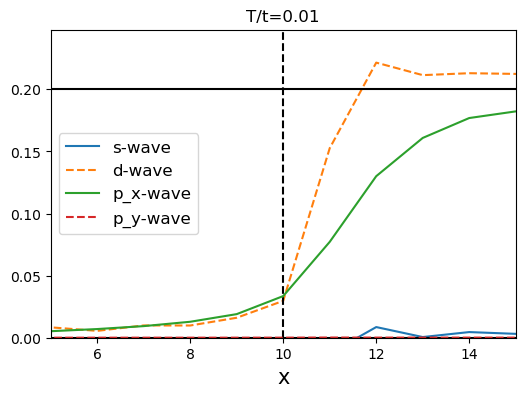

In [6]:

x = np.arange(1, widthN + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
axs.set_title(f"T/t={T}")
axs.plot(x, np.real(F_swave), label="s-wave")
axs.plot(x, np.real(F_dwave), '--', label="d-wave")
axs.axhline(0, color = 'black')
axs.axhline(0.2, color = 'black')

axs.axvline(widthN, color='black', linestyle='--')
axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(5, 15)
axs.set_ylim(0, None)
axs.legend(fontsize=12, loc="best")
plt.show()